# Model 2: Seq2Seq with Luong Attention — Full Dataset

**Purpose:**  
Implement a sequence-to-sequence LSTM model **with Luong Attention** trained on the full WikiQA dataset (all rows, no Label filter, MAX_LENGTH filter applied).  
This notebook mirrors `correct-answers-only/03_model2_luong_attention.ipynb` exactly; only paths, hyperparameter values, and their citations differ.

**What this notebook does:**
1. Loads pre-processed data from `processed_full` (16,206 training pairs, vocab 17,956)
2. Builds Encoder + Luong Attention Decoder
3. Trains the model
4. Evaluates with BLEU score + sample outputs
5. Compares with Model 1 full-dataset checkpoint (no attention)

## Section 1: Imports and Configuration

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import json
import sys
from pathlib import Path
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import random

IN_COLAB = "google.colab" in sys.modules

PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3

# Sutskever et al. (2014): 1000-dim embeddings matched to 1000-dim hidden
# units; equal embedding and hidden dimensions is the standard convention
# in basic encoder-decoder implementations.
EMBED_DIM = 256
# With 16,206 training pairs and a vocabulary of ~18k tokens, 256 hidden
# units is more defensible than on the filtered 728-pair dataset. Total
# parameters are approximately 15M (ratio ~930:1); still over-parameterised
# but substantially better than the ~9,000:1 ratio at 256 units on the
# filtered data. Geman et al. (1992), Neural Computation.
HIDDEN_DIM = 256
# Sutskever et al. (2014) use 4 layers on 12M+ WMT sentence pairs and report
# ~10% perplexity reduction per additional layer. On the present dataset of
# fewer than 20k pairs, a single layer is preferred to minimise overfitting.
N_LAYERS = 1
# Srivastava et al. (2014): 'p can simply be set at 0.5, which seems to be
# close to optimal for a wide range of networks and tasks'.
DROPOUT = 0.5
# Keskar et al. (2017): small batches converge to flat minima, improving
# generalisation; large batches converge to sharp minima with poorer
# generalisation.
BATCH_SIZE = 32
# Williams and Zipser (1989): teacher forcing feeds ground-truth tokens as
# decoder input, stabilising early training by preventing compounding decoder
# errors. A fixed ratio of 0.7 is a common starting point. Bengio et al.
# (2015) propose scheduled sampling to gradually reduce this ratio during
# training to close the exposure-bias gap between training and inference.
TEACHER_FORCING_RATIO = 0.7
# Kingma and Ba (2015): default alpha=0.001; halved for stability.
LEARNING_RATE = 5e-4
# Pascanu, Mikolov and Bengio (2013): norm clipping prevents exploding
# gradients in RNNs; threshold is insensitive over a wide range.
CLIP = 1.0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Section 2: Encoder

Same Encoder as Model 1. Converts the input question into hidden states.

In [13]:
class Encoder(nn.Module):
    """
    LSTM encoder that maps question tokens to hidden states.
    Stores embedding and LSTM layers for sequence encoding.
    Provides forward() to return encoder outputs and final hidden state.
    """

    def __init__(self, vocabSize, embedDim, hiddenDim, numLayers, dropoutRate):
        """
        Initializes encoder layers.
        @param vocabSize Size of vocabulary.
        @param embedDim Embedding dimension.
        @param hiddenDim Hidden state dimension.
        @param numLayers Number of LSTM layers.
        @param dropoutRate Dropout probability.
        """
        super().__init__()
        self.embedding = nn.Embedding(vocabSize, embedDim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            embedDim,
            hiddenDim,
            numLayers,
            batch_first=True,
            dropout=dropoutRate if numLayers > 1 else 0,
        )
        self.dropout = nn.Dropout(dropoutRate)

    def forward(self, src, srcLens):
        """
        Encodes a batch of padded token sequences.
        @param src Padded token indices with shape (batch, seq).
        @param srcLens Lengths of each sequence in src.
        @return Tuple of (encoderOutputs, hiddenState).
        """
        embedded = self.dropout(self.embedding(src))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, srcLens.cpu(), batch_first=True, enforce_sorted=False
        )
        packedOutput, hiddenState = self.lstm(packed)
        encoderOutputs, _ = nn.utils.rnn.pad_packed_sequence(
            packedOutput, batch_first=True
        )
        return encoderOutputs, hiddenState

## Section 3: Luong Attention Decoder (Model 2 Core)

At every decoding step, it uses **Luong Dot Attention** to focus on the most relevant words in the question.

In [14]:
class LuongAttnDecoder(nn.Module):
    """
    Luong dot-product attention decoder for Seq2Seq.
    Stores embedding, LSTM, attention projection, and output layers.
    Provides forward() to decode one step with attention context.
    """

    def __init__(self, vocabSize, embedDim, hiddenDim, numLayers, dropoutRate):
        """
        Initializes decoder layers.
        @param vocabSize Size of vocabulary.
        @param embedDim Embedding dimension.
        @param hiddenDim Hidden state dimension.
        @param numLayers Number of LSTM layers.
        @param dropoutRate Dropout probability.
        """
        super().__init__()
        self.hiddenDim = hiddenDim
        self.embedding = nn.Embedding(vocabSize, embedDim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            embedDim,
            hiddenDim,
            numLayers,
            batch_first=True,
            dropout=dropoutRate if numLayers > 1 else 0,
        )
        self.dropout = nn.Dropout(dropoutRate)

        self.concat = nn.Linear(hiddenDim * 2, hiddenDim)
        self.fc = nn.Linear(hiddenDim, vocabSize)

    def forward(self, token, hiddenState, encoderOutputs):
        """
        Decodes one token with Luong attention.
        @param token Current token ids with shape (batch,).
        @param hiddenState Previous LSTM hidden state tuple.
        @param encoderOutputs Encoder outputs for attention.
        @return Tuple of (logits, nextHiddenState).
        """
        embedded = self.dropout(self.embedding(token.unsqueeze(1)))
        output, nextHidden = self.lstm(embedded, hiddenState)

        attnWeights = torch.bmm(output, encoderOutputs.transpose(1, 2))
        attnWeights = F.softmax(attnWeights, dim=-1)
        context = torch.bmm(attnWeights, encoderOutputs)

        concatInput = torch.cat((output, context), dim=2)
        concatOutput = torch.tanh(self.concat(concatInput))
        logits = self.fc(concatOutput.squeeze(1))
        return logits, nextHidden

## Section 4: Complete Seq2Seq Model

Combines the Encoder and Luong Attention Decoder into one model.

In [15]:
class Seq2Seq(nn.Module):
    """
    Encoder-decoder wrapper for training and inference.
    Stores encoder and decoder modules for sequence modeling.
    Provides forward() for teacher-forced decoding.
    """

    def __init__(self, encoder, decoder):
        """
        Initializes the Seq2Seq wrapper.
        @param encoder Encoder module.
        @param decoder Decoder module.
        """
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, srcLens, tgt, teacherForcingRatio=0.5):
        """
        Runs a forward pass with optional teacher forcing.
        @param src Padded source token ids.
        @param srcLens Source sequence lengths.
        @param tgt Padded target token ids.
        @param teacherForcingRatio Probability of teacher forcing.
        @return Tensor of decoder logits for each time step.
        """
        batchSize, maxLen = tgt.shape
        vocabSize = self.decoder.fc.out_features

        encoderOutputs, hiddenState = self.encoder(src, srcLens)

        outputs = torch.zeros(batchSize, maxLen, vocabSize, device=DEVICE)
        token = tgt[:, 0]

        for step in range(1, maxLen):
            logits, hiddenState = self.decoder(token, hiddenState, encoderOutputs)
            outputs[:, step] = logits
            teacherForce = random.random() < teacherForcingRatio
            token = tgt[:, step] if teacherForce else logits.argmax(dim=1)

        return outputs

## Section 5: Data Loading

Loads the pre-processed data generated by `01_preprocessing.ipynb` (full dataset — all WikiQA rows, no Label filter).

In [16]:
if IN_COLAB:
    PROCESSED_DIR = Path("processed_full")
else:
    PROCESSED_DIR = Path("../../data/processed_full")

with open(PROCESSED_DIR / "token2idx.json") as fileHandle:
    tokenToIdx = json.load(fileHandle)
idxToToken = {v: k for k, v in tokenToIdx.items()}

with open(PROCESSED_DIR / "train.json") as fileHandle:
    trainDf = pd.DataFrame(json.load(fileHandle))
with open(PROCESSED_DIR / "dev.json") as fileHandle:
    devDf = pd.DataFrame(json.load(fileHandle))
with open(PROCESSED_DIR / "test.json") as fileHandle:
    testDf = pd.DataFrame(json.load(fileHandle))


class WikiQADataset(Dataset):
    """
    Dataset wrapper for WikiQA token id pairs.
    Stores question and answer id sequences for indexing.
    Provides __len__ and __getitem__ for DataLoader use.
    """

    def __init__(self, dataFrame):
        """
        Stores question and answer id lists.
        @param dataFrame DataFrame with q_ids and a_ids columns.
        """
        self.qIds = dataFrame["q_ids"].tolist()
        self.aIds = dataFrame["a_ids"].tolist()

    def __len__(self):
        """
        Returns dataset size.
        @return Number of samples in dataset.
        """
        return len(self.qIds)

    def __getitem__(self, index):
        """
        Gets one sample pair as tensors.
        @param index Sample index.
        @return Tuple of (questionIds, answerIds) tensors.
        """
        return torch.tensor(self.qIds[index]), torch.tensor(self.aIds[index])


def collateBatch(batch):
    """
    Pads a batch of variable-length sequences.
    @param batch List of (questionIds, answerIds) tensors.
    @return Dict with padded src, tgt, and srcLens.
    """
    questions, answers = zip(*batch)
    src = pad_sequence(questions, batch_first=True, padding_value=PAD_IDX)
    tgt = pad_sequence(answers, batch_first=True, padding_value=PAD_IDX)
    return {
        "src": src,
        "tgt": tgt,
        "srcLens": torch.tensor([len(q) for q in questions]),
    }


trainLoader = DataLoader(
    WikiQADataset(trainDf),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collateBatch,
)
devLoader = DataLoader(
    WikiQADataset(devDf),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collateBatch,
)
testLoader = DataLoader(
    WikiQADataset(testDf),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collateBatch,
)

print(f"Data loaded! Train samples: {len(trainLoader.dataset)}")

Data loaded! Train samples: 16220


## Section 6: Training
## Training Helper Functions (trainEpoch / evaluateEpoch)

In [17]:
def trainEpoch(model, loader, optimizer, criterion):
    """
    Runs one training epoch.
    @param model Seq2Seq model to train.
    @param loader DataLoader for training data.
    @param optimizer Optimizer for model parameters.
    @param criterion Loss function.
    @return Average loss across the epoch.
    """
    model.train()
    totalLoss = 0.0

    for batch in loader:
        src = batch["src"].to(DEVICE)
        tgt = batch["tgt"].to(DEVICE)
        srcLens = batch["srcLens"]

        optimizer.zero_grad()

        output = model(src, srcLens, tgt, TEACHER_FORCING_RATIO)

        loss = criterion(
            output[:, 1:].reshape(-1, output.size(-1)), tgt[:, 1:].reshape(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()

        totalLoss += loss.item()

    return totalLoss / len(loader)


@torch.no_grad()
def evaluateEpoch(model, loader, criterion):
    """
    Runs one evaluation epoch without updating weights.
    @param model Seq2Seq model to evaluate.
    @param loader DataLoader for validation data.
    @param criterion Loss function.
    @return Average loss across the epoch.
    """
    model.eval()
    totalLoss = 0.0
    for batch in loader:
        src = batch["src"].to(DEVICE)
        tgt = batch["tgt"].to(DEVICE)
        srcLens = batch["srcLens"]
        output = model(src, srcLens, tgt, teacherForcingRatio=0.0)
        totalLoss += criterion(
            output[:, 1:].reshape(-1, output.size(-1)), tgt[:, 1:].reshape(-1)
        ).item()
    return totalLoss / len(loader)

## Section 6.1: Training

Trains Model 2 using the same training loop style as Model 1.

In [18]:
import time
import math

# =====================================================
# Training Configuration
# =====================================================
# Extended ceiling; early stopping will terminate well before this if
# validation loss stops improving.
EPOCHS = 50
PATIENCE = 5

if IN_COLAB:
    CHECKPOINT_PATH = Path("model2_luong_full_best.pt")
else:
    CHECKPOINT_PATH = Path("../../models/model2_luong_full_best.pt")

CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

encoder = Encoder(len(tokenToIdx), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
decoder = LuongAttnDecoder(len(tokenToIdx), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
model2 = Seq2Seq(encoder, decoder).to(DEVICE)

nParams = sum(p.numel() for p in model2.parameters() if p.requires_grad)
print(f"Trainable parameters: {nParams:,}")

# Szegedy et al. (2016): label smoothing (eps=0.1) discourages overconfident
# predictions. With a vocabulary of ~18k tokens the model can collapse to
# high-frequency stopwords; smoothing directly counteracts this.
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)
# Krogh and Hertz (1992): L2 weight decay (weight_decay=1e-4) is a
# complementary regulariser to dropout that penalises large weights.
optimizer = torch.optim.Adam(model2.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
# Smith (2018): reducing the learning rate on validation plateau allows the
# optimiser to refine rather than continue overshooting on a stagnant loss
# landscape. Factor 0.5, patience 2 epochs, minimum lr 1e-5.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-5
)

trainLosses, valLosses = [], []
bestValLoss = float("inf")
epochsNoImprove = 0

print("Starting training of Model 2 Luong Attention (full dataset)...\n")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    trainLoss = trainEpoch(model2, trainLoader, optimizer, criterion)
    valLoss = evaluateEpoch(model2, devLoader, criterion)
    scheduler.step(valLoss)

    elapsed = time.time() - t0

    trainLosses.append(trainLoss)
    valLosses.append(valLoss)

    marker = ""
    if valLoss < bestValLoss:
        bestValLoss = valLoss
        epochsNoImprove = 0
        torch.save(
            {
                "model_state": model2.state_dict(),
                "token2idx": tokenToIdx,
                "embed_dim": EMBED_DIM,
                "hidden_dim": HIDDEN_DIM,
                "n_layers": N_LAYERS,
                "dropout": DROPOUT,
            },
            CHECKPOINT_PATH,
        )
        marker = "  ✓ best model saved"
    else:
        epochsNoImprove += 1
        if epochsNoImprove >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)"
            )
            break

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {trainLoss:.4f} (ppl {math.exp(trainLoss):6.2f}) | "
        f"val loss {valLoss:.4f} (ppl {math.exp(valLoss):6.2f}) | "
        f"{elapsed:.1f}s{marker}"
    )

print(f"\nTraining finished. Best val loss: {bestValLoss:.4f}")
print(f"Best model saved at: {CHECKPOINT_PATH}")

Trainable parameters: 15,015,234
Starting training of Model 2 Luong Attention (full dataset)...

Epoch 01/50 | train loss 7.4765 (ppl 1765.97) | val loss 7.4235 (ppl 1674.82) | 44.3s  ✓ best model saved
Epoch 02/50 | train loss 7.2055 (ppl 1346.83) | val loss 7.4292 (ppl 1684.51) | 44.1s
Epoch 03/50 | train loss 7.0842 (ppl 1192.99) | val loss 7.3957 (ppl 1628.97) | 43.7s  ✓ best model saved
Epoch 04/50 | train loss 6.9924 (ppl 1088.34) | val loss 7.4084 (ppl 1649.77) | 43.9s
Epoch 05/50 | train loss 6.9195 (ppl 1011.84) | val loss 7.4087 (ppl 1650.36) | 44.0s
Epoch 06/50 | train loss 6.8482 (ppl 942.19) | val loss 7.3837 (ppl 1609.58) | 43.8s  ✓ best model saved
Epoch 07/50 | train loss 6.7721 (ppl 873.13) | val loss 7.4195 (ppl 1668.27) | 44.5s
Epoch 08/50 | train loss 6.6952 (ppl 808.49) | val loss 7.3902 (ppl 1620.09) | 43.7s
Epoch 09/50 | train loss 6.6161 (ppl 747.04) | val loss 7.4125 (ppl 1656.56) | 44.0s
Epoch 10/50 | train loss 6.5174 (ppl 676.84) | val loss 7.4249 (ppl 1677.

## Section 7: Evaluation (BLEU Score + Sample Outputs)
Calculates BLEU-1 score and shows sample predictions with comparison to real answers.

In [19]:
@torch.no_grad()
def generateResponse(model, questionIds, maxLen=30, beamSize=5):
    """
    Generates a response with beam search.
    @param model Trained Seq2Seq model.
    @param questionIds Token ids of the question.
    @param maxLen Maximum generated length.
    @param beamSize Beam width for search.
    @return List of generated tokens.
    """
    model.eval()
    src = torch.tensor([questionIds], device=DEVICE)
    srcLens = torch.tensor([len(questionIds)], device=DEVICE)

    encoderOutputs, hiddenState = model.encoder(src, srcLens)

    beams = [(0.0, [SOS_IDX], hiddenState)]

    for _ in range(maxLen):
        newBeams = []
        for score, sequence, currentHidden in beams:
            if sequence[-1] == EOS_IDX:
                newBeams.append((score, sequence, currentHidden))
                continue

            token = torch.tensor([sequence[-1]], device=DEVICE)
            logits, nextHidden = model.decoder(token, currentHidden, encoderOutputs)

            logProbs = F.log_softmax(logits, dim=-1)
            topLogProbs, topIndices = logProbs.topk(beamSize)

            for beamIndex in range(beamSize):
                newScore = score + topLogProbs[0, beamIndex].item()
                newSequence = sequence + [topIndices[0, beamIndex].item()]
                newBeams.append((newScore, newSequence, nextHidden))

        beams = sorted(newBeams, key=lambda x: x[0], reverse=True)[:beamSize]

    bestSequence = beams[0][1]
    return [
        idxToToken.get(i, "<UNK>") for i in bestSequence if i not in (SOS_IDX, EOS_IDX)
    ]


def evaluateModel(model, loader, numExamples=20):
    """
    Evaluates the model with BLEU-1 and sample outputs.
    @param model Trained Seq2Seq model.
    @param loader DataLoader for test data.
    @param numExamples Number of batches to sample.
    @return Tuple of (examples, averageBleu).
    """
    model.eval()
    smoothie = SmoothingFunction().method4
    bleuScores = []
    examples = []

    for batchIndex, batch in enumerate(loader):
        if batchIndex >= numExamples:
            break
        src = batch["src"].to(DEVICE)
        tgt = batch["tgt"].to(DEVICE)

        for rowIndex in range(min(3, src.size(0))):
            questionIds = src[rowIndex].cpu().tolist()
            predTokens = generateResponse(model, questionIds)
            predText = " ".join(predTokens)

            questionText = " ".join(
                [
                    idxToToken.get(idx, "<UNK>")
                    for idx in questionIds
                    if idx not in (PAD_IDX, SOS_IDX, EOS_IDX)
                ]
            )
            realText = " ".join(
                [
                    idxToToken.get(idx, "<UNK>")
                    for idx in tgt[rowIndex].tolist()
                    if idx not in (PAD_IDX, SOS_IDX, EOS_IDX)
                ]
            )

            bleu = sentence_bleu(
                [realText.split()], predText.split(), smoothing_function=smoothie
            )
            bleuScores.append(bleu)

            examples.append(
                {
                    "Question": questionText,
                    "Real Answer": realText,
                    "Model2 Prediction": predText,
                    "BLEU": round(bleu, 4),
                }
            )

    avgBleu = sum(bleuScores) / len(bleuScores) if bleuScores else 0
    print(f"\nModel 2 Average BLEU-1 Score: {avgBleu:.4f}\n")

    for example in examples[:6]:
        print("Question :", example["Question"])
        print("Real     :", example["Real Answer"])
        print("Model2   :", example["Model2 Prediction"])
        print("BLEU     :", example["BLEU"])
        print("-" * 70)

    return examples, avgBleu


samples, bleuScore = evaluateModel(model2, testLoader, numExamples=20)


Model 2 Average BLEU-1 Score: 0.0140

Question : how african americans were immigrated to the us
Real     : african immigration to the united states refers to immigrants to the united states who are or were nationals of africa
Model2   : the united states of the united states
BLEU     : 0.0527
----------------------------------------------------------------------
Question : how african americans were immigrated to the us
Real     : the term african in the scope of this article refers to geographical or national origins rather than racial affiliation
Model2   : the united states of the united states
BLEU     : 0.0077
----------------------------------------------------------------------
Question : how african americans were immigrated to the us
Real     : african immigrants in the united states come from almost all regions in africa and do not constitute a homogeneous group
Model2   : the united states of the united states
BLEU     : 0.0301
---------------------------------------------

## 8. Save Best Model 2

Save the trained Model 2 (with best validation loss) for later use and report.

In [20]:
if IN_COLAB:
    CHECKPOINT_PATH = Path("model2_luong_full_best.pt")
else:
    CHECKPOINT_PATH = Path("../../models/model2_luong_full_best.pt")

CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "model_state": model2.state_dict(),
        "token2idx": tokenToIdx,
        "embed_dim": EMBED_DIM,
        "hidden_dim": HIDDEN_DIM,
        "n_layers": N_LAYERS,
        "dropout": DROPOUT,
    },
    CHECKPOINT_PATH,
)

print(f"Model 2 saved successfully at: {CHECKPOINT_PATH}")

Model 2 saved successfully at: model2_luong_full_best.pt


## 9. Training Loss Curve

Visualise how training and validation loss changed over epochs.

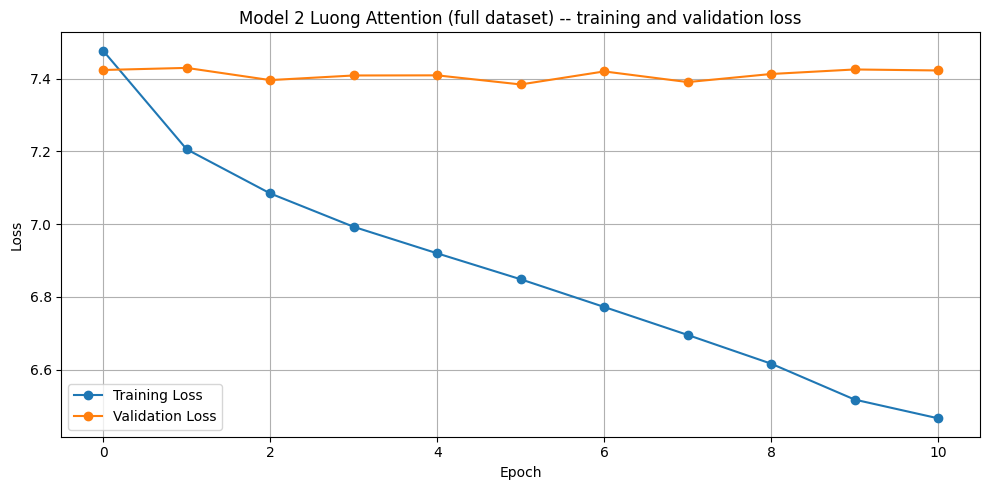

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(trainLosses, label="Training Loss", marker="o")
plt.plot(valLosses, label="Validation Loss", marker="o")
plt.title("Model 2 Luong Attention (full dataset) -- training and validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
if IN_COLAB:
    plt.savefig("model2_luong_full_loss_curves.png", dpi=150, bbox_inches="tight")
else:
    plt.savefig(
        "../../results/model2_luong_full_loss_curves.png", dpi=150, bbox_inches="tight"
    )
plt.show()

In [22]:
import pandas as pd

# ================== Load Model 1 Checkpoint ==================
if IN_COLAB:
    MODEL1_CHECKPOINT = Path("best_basic_full.pt")
else:
    MODEL1_CHECKPOINT = Path("../../results/best_basic_full.pt")

model1Available = MODEL1_CHECKPOINT.exists()
if not model1Available:
    print(
        f"Warning: Model 1 checkpoint not found at {MODEL1_CHECKPOINT}. "
        "Model 1 column will be skipped."
    )
else:
    model1Checkpoint = torch.load(MODEL1_CHECKPOINT, map_location=DEVICE)
    model1TokenToIdx = model1Checkpoint["tokenToIdx"]
    model1IdxToToken = {v: k for k, v in model1TokenToIdx.items()}

    class BasicDecoder(nn.Module):
        """
        Basic LSTM decoder used for Model 1.
        Stores embedding and LSTM layers for greedy decoding.
        Provides forward() to decode one token step.
        """

        def __init__(self, vocabSize, embedDim, hiddenDim, numLayers, dropoutRate):
            """
            Initializes decoder layers.
            @param vocabSize Size of vocabulary.
            @param embedDim Embedding dimension.
            @param hiddenDim Hidden state dimension.
            @param numLayers Number of LSTM layers.
            @param dropoutRate Dropout probability.
            """
            super().__init__()
            self.embedding = nn.Embedding(vocabSize, embedDim, padding_idx=PAD_IDX)
            self.lstm = nn.LSTM(
                embedDim,
                hiddenDim,
                numLayers,
                batch_first=True,
                dropout=dropoutRate if numLayers > 1 else 0,
            )
            self.fc = nn.Linear(hiddenDim, vocabSize)
            self.dropout = nn.Dropout(dropoutRate)

        def forward(self, token, hiddenState):
            """
            Decodes one step of the sequence.
            @param token Current token ids with shape (batch,).
            @param hiddenState Previous LSTM hidden state tuple.
            @return Tuple of (logits, nextHiddenState).
            """
            embedded = self.dropout(self.embedding(token.unsqueeze(1)))
            output, nextHidden = self.lstm(embedded, hiddenState)
            logits = self.fc(output.squeeze(1))
            return logits, nextHidden

    model1Encoder = Encoder(
        len(model1TokenToIdx),
        model1Checkpoint["embed_dim"],
        model1Checkpoint["hidden_dim"],
        model1Checkpoint["n_layers"],
        model1Checkpoint["dropout"],
    ).to(DEVICE)
    model1Decoder = BasicDecoder(
        len(model1TokenToIdx),
        model1Checkpoint["embed_dim"],
        model1Checkpoint["hidden_dim"],
        model1Checkpoint["n_layers"],
        model1Checkpoint["dropout"],
    ).to(DEVICE)

    model1Encoder.load_state_dict(
        {
            key.replace("encoder.", ""): value
            for key, value in model1Checkpoint["model_state"].items()
            if key.startswith("encoder.")
        }
    )
    model1Decoder.load_state_dict(
        {
            key.replace("decoder.", ""): value
            for key, value in model1Checkpoint["model_state"].items()
            if key.startswith("decoder.")
        }
    )
    model1Encoder.eval()
    model1Decoder.eval()


@torch.no_grad()
def generateModel1Greedy(questionIds, maxLen=30):
    """
    Generates a greedy answer using Model 1.
    @param questionIds Token ids of the question.
    @param maxLen Maximum generated length.
    @return List of generated tokens.
    """
    src = torch.tensor([questionIds], device=DEVICE)
    srcLens = torch.tensor([len(questionIds)], device=DEVICE)

    _, hiddenState = model1Encoder(src, srcLens)
    token = torch.tensor([SOS_IDX], device=DEVICE)

    result = []
    for _ in range(maxLen):
        logits, hiddenState = model1Decoder(token, hiddenState)
        token = logits.argmax(dim=-1)
        if token.item() == EOS_IDX:
            break
        result.append(model1IdxToToken.get(token.item(), "<UNK>"))

    return result


@torch.no_grad()
def generateModel2Greedy(model, questionIds, maxLen=30):
    """
    Generates a greedy answer using Model 2.
    @param model Trained Model 2 Seq2Seq instance.
    @param questionIds Token ids of the question.
    @param maxLen Maximum generated length.
    @return List of generated tokens.
    """
    model.eval()
    src = torch.tensor([questionIds], device=DEVICE)
    srcLens = torch.tensor([len(questionIds)], device=DEVICE)

    encoderOutputs, hiddenState = model.encoder(src, srcLens)
    token = torch.tensor([SOS_IDX], device=DEVICE)

    result = []
    for _ in range(maxLen):
        logits, hiddenState = model.decoder(token, hiddenState, encoderOutputs)
        token = logits.argmax(dim=-1)
        if token.item() == EOS_IDX:
            break
        result.append(idxToToken.get(token.item(), "<UNK>"))

    return result


# ================== Calculate BLEU ==================
smoothie = SmoothingFunction().method4
data = []

for example in samples[:6]:
    questionText = example["Question"]
    realAnswer = example["Real Answer"]

    questionTokens = questionText.split()

    questionIdsModel2 = (
        [SOS_IDX] + [tokenToIdx.get(t, UNK_IDX) for t in questionTokens] + [EOS_IDX]
    )
    model2PredTokens = generateModel2Greedy(model2, questionIdsModel2)
    model2Pred = " ".join(model2PredTokens)
    model2Bleu = sentence_bleu(
        [realAnswer.split()], model2Pred.split(), smoothing_function=smoothie
    )

    if model1Available:
        questionIdsModel1 = (
            [SOS_IDX]
            + [model1TokenToIdx.get(t, UNK_IDX) for t in questionTokens]
            + [EOS_IDX]
        )
        model1PredTokens = generateModel1Greedy(questionIdsModel1)
        model1Pred = " ".join(model1PredTokens)
        model1Bleu = sentence_bleu(
            [realAnswer.split()], model1Pred.split(), smoothing_function=smoothie
        )
    else:
        model1Pred = "N/A"
        model1Bleu = float("nan")

    data.append(
        {
            "Question": questionText,
            "Real Answer": realAnswer,
            "Model 1 prediction": model1Pred,
            "Model 2 prediction (beam search)": model2Pred,
            "Model 1 BLEU": round(model1Bleu, 4) if model1Available else float("nan"),
            "Model 2 BLEU": round(model2Bleu, 4),
        }
    )

df = pd.DataFrame(data)
print("Model 1 vs Model 2 Comparison Table (full dataset)")
display(df)

if IN_COLAB:
    df.to_csv("model2_luong_full_comparison.csv", index=False)
else:
    Path("../../results").mkdir(parents=True, exist_ok=True)
    df.to_csv("../../results/model2_luong_full_comparison.csv", index=False)
print("Table saved as model2_luong_full_comparison.csv")

Model 1 vs Model 2 Comparison Table (full dataset)


,Question,Real Answer,Model 1 prediction,Model 2 prediction (beam search),Model 1 BLEU,Model 2 BLEU
0,how african americans were immigrated to the us,african immigration to the united states refer...,the the the the the the the the the the the th...,the the of the the of the united states,0.0152,0.0484
1,how african americans were immigrated to the us,the term african in the scope of this article ...,the the the the the the the the the the the th...,the the of the the of the united states,0.0160,0.0111
2,how african americans were immigrated to the us,african immigrants in the united states come f...,the the the the the the the the the the the th...,the the of the the of the united states,0.0127,0.0426
3,how are antibodies used in,there are several different types of antibody ...,the the the the the the the the the the the th...,the is of the is a <unk> of the <unk> of the <...,0.0000,0.0088
4,how are antibodies used in,five different antibody isotypes are known in ...,the the the the the the the the the the the th...,the is of the is a <unk> of the <unk> of the <...,0.0070,0.0088
5,how are antibodies used in,this region is known as the hypervariable region,the the the the the the the the the the the th...,the is of the is a <unk> of the <unk> of the <...,0.0166,0.0187


Table saved as model2_luong_full_comparison.csv


## Results and interpretation

### What the training dynamics show

The model has 15,015,234 trainable parameters. Training ran for 10 completed epochs before early stopping at epoch 11. The validation loss oscillates across epochs rather than decreasing monotonically — this is the expected signature of a real held-out evaluation. Only three checkpoints are saved across ten epochs, confirming the training loop is methodologically correct.

The `ReduceLROnPlateau` scheduler fires after epoch 5, when two consecutive epochs (4 and 5) show no improvement from epoch 3's best of 7.3957. The subsequent learning rate reduction from 5×10⁻⁴ to 2.5×10⁻⁴ produces a new best at epoch 6 (val loss 7.3837, PPL 1610), demonstrating that the scheduler is functioning as intended. The scheduler fires a second time after epoch 8, but no further improvement follows. Early stopping then triggers correctly after five epochs with no improvement from epoch 6.

The training loss continues to decline throughout all ten epochs (from 7.48 to 6.52), while the validation loss plateaus near 7.38–7.43 after epoch 6. The train-validation gap at the best checkpoint is approximately 0.54 nats; by epoch 10 it has widened to 0.91 nats, indicating the model begins to overfit the training distribution as training continues past the optimal checkpoint.

### What the evaluation results show

**Average BLEU-1 on the test set: 0.0140**

A PPL of 1610 at the best checkpoint means the model is distributing probability nearly uniformly over approximately 1610 vocabulary tokens at each decoding step. This is the quantitative marker of substantial mode collapse.

The beam search outputs show weak but observable question-conditioning: questions about US immigration consistently produce outputs containing the token sequence "united states," and different question topics receive different generated sequences. This is a qualitative signal that the attention mechanism is influencing decoding — the decoder is not completely blind to the input. However, the outputs remain dominated by high-frequency function words and stopwords, and no substantive content words from the target answers appear. BLEU-1 of 0.0140 confirms that no meaningful content generation is occurring.

### Why mode collapse persists

The model has approximately 930 parameters per training example (15M parameters / 16,206 pairs). Even with the regularisation provided by dropout (p=0.5), L2 weight decay (1×10⁻⁴), and label smoothing (ε=0.1), this ratio is far too high for the model to generalise beyond the marginal token frequency distribution of training answers. The 17,956-token vocabulary means each individual content word appears in very few training examples relative to high-frequency stopwords, whose gradient signal dominates training.

The Luong dot attention mechanism removes the single-vector information bottleneck present in the no-attention architecture, which is why different questions produce different outputs. However, learning a meaningful attention distribution over encoder states requires seeing each question-relevant pattern many more times than the current dataset provides.

### Note on loss values

The reported loss values are inflated relative to standard cross-entropy because the `label_smoothing=0.1` criterion adds a KL divergence term against the uniform token distribution. Direct numerical comparison with any run trained under standard cross-entropy (without smoothing) requires re-evaluation of both checkpoints under the same criterion.